In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import ACTIONet as an
import scanpy as sc


# Imports PBMC 68k reduced dataset from scanpy

In [9]:
adata = sc.datasets.pbmc68k_reduced()

adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

# Perform reduction (if necessary)

In [10]:
an.pp.reduce_adata(adata)

adata

Computing reduced ACTION kernel (dense):
	Performing SVD on original matrix: IRLB (dense) -- A: 765 x 700


AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'metadata', 'ACTION', 'obsm_annot', 'varm_annot'
    obsm: 'X_pca', 'X_umap', 'ACTION', 'ACTION_B'
    varm: 'PCs', 'ACTION_V', 'ACTION_A'
    obsp: 'distances', 'connectivities'

# Run ACTIONet

In [11]:
an.run_ACTIONet(adata)


Running ACTION (62 threads):
	Iterating from k = 2 ... 30: 29/29 finished
Joining trace of C & H matrices (depth = 30) ... done (464 archetypes)
Pruning archetypes:
	Non-specific archetypes: 5
	Unreliable archetypes: 0
	Trivial archetypes: 107
Unifying 353 archetypes (62 threads):
# unified archetypes: 17
Building adaptive network (density = 1.00)
	Building index ... done
	Identifying nearest neighbors ... done
	Constructing adaptive-nearest neighbor graph ... done
	Finalizing network ... 
		Keeping mutual nearest-neighbors only ... done
Laying-out input network: method = umap, a = 0.115, b = 1.929 (epochs = 100, threads=62)
Computing 2D layout ... done
Computing 3D layout ... done
Computing de novo node colors ... done
Computing feature specificity ... done
Building adaptive network (density = 0.50)
	Building index ... done
	Identifying nearest neighbors ... done
	Constructing adaptive-nearest neighbor graph ... done
	Finalizing network ... 
		Keeping mutual nearest-neighbors only ...

In [12]:
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain', 'assigned_archetype', 'node_centrality'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'metadata', 'ACTION', 'obsm_annot', 'varm_annot'
    obsm: 'X_pca', 'X_umap', 'ACTION', 'ACTION_B', 'ACTION_normalized', 'C_stacked', 'H_stacked', 'C_unified', 'H_unified', 'archetype_footprint', 'ACTIONred', 'ACTIONet2D', 'ACTIONet3D', 'denovo_color'
    varm: 'PCs', 'ACTION_V', 'ACTION_A', 'unified_feature_profile', 'unified_feature_specificity'
    obsp: 'distances', 'connectivities', 'ACTIONet'

# Visualize output

[<Axes: title={'center': 'bulk_labels'}, xlabel='actionet2d1', ylabel='actionet2d2'>,
 <Axes: title={'center': 'phase'}, xlabel='actionet2d1', ylabel='actionet2d2'>,
 <Axes: title={'center': 'louvain'}, xlabel='actionet2d1', ylabel='actionet2d2'>,
 <Axes: title={'center': 'assigned_archetype'}, xlabel='actionet2d1', ylabel='actionet2d2'>]

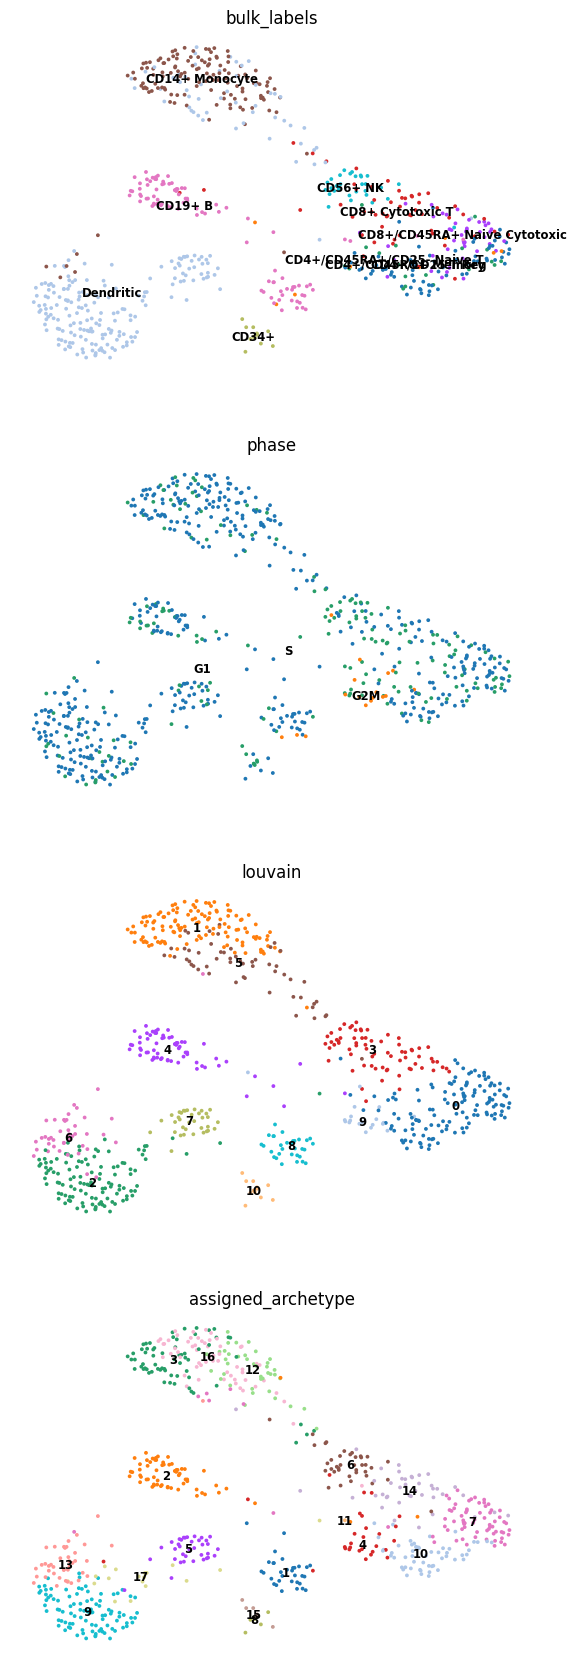

In [24]:
an.pl.plot_ACTIONet(adata, annotation=['bulk_labels', "phase", "louvain", "assigned_archetype"], ncols=1, size = 30)
